### **Purpose:** load all raw CSVs, standardize date column, merge by date, and create train/test tables.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import glob
from pathlib import Path

In [2]:
pd.set_option('display.max_columns', None)  # Show ALL columns, don't hide any
pd.set_option('display.max_rows', 100)     # Show up to 100 rows
pd.set_option('display.precision', 2)

In [3]:
warnings.filterwarnings('ignore')

In [4]:
train_dir = Path("../data/raw/train")
test_dir = Path("../data/raw/test")

In [5]:
train_files = sorted(train_dir.glob("*.csv"))
test_files = sorted(test_dir.glob("*.csv"))

In [6]:
print("Train files:", [f.name for f in train_files])
print("Test files:", [f.name for f in test_files])

Train files: ['5cm soil moist CFS_train.csv', 'dew point_train.csv', 'max surface temp era5 max_train.csv', 'sea level pressure era5_train.csv', 'solution_train.csv', 'sst_cameroon_train.csv', 'sst_indian_ocean_train.csv', 'sudd water deficit_train.csv', 'surface pressure era5_train.csv', 'temp_trimmed_train.csv', 'u10_2002_2019_JulOct_train.csv', 'vapour pressure deficit_train.csv']
Test files: ['5cm soil moist CFS_test.csv', 'dew point_test.csv', 'max surface temp era5 max_test.csv', 'sea level pressure era5_test.csv', 'sst_cameroon_test.csv', 'sst_indian_ocean_test.csv', 'sudd water deficit_test.csv', 'surface pressure era5_test.csv', 'temp_trimmed_test.csv', 'u10_2020_2025_JulOct_test.csv', 'vapour pressure deficit_test.csv']


In [7]:
def load_csv(path, prefix=None):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
    
    # normalize date column
    if "date" not in df.columns and "dates" in df.columns:
        df = df.rename(columns={"dates": "date"})
    if "date" not in df.columns and "valid_time" in df.columns:
        df = df.rename(columns={"valid_time": "date"})
    if "date" not in df.columns:
        df = df.rename(columns={df.columns[0]: "date"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
 
    # aggregate u10 grid to daily mean
    lat_cols = {"latitude", "lat"}
    lon_cols = {"longitude", "lon", "long"}
    if lat_cols.intersection(df.columns) and lon_cols.intersection(df.columns) and "u10" in df.columns:
        df = df.groupby("date", as_index=False)["u10"].mean()
   
    # prefix to avoid _x/_y for SST files
    if prefix:
        df = df.rename(columns={c: f"{prefix}_{c}" for c in df.columns if c != "date"})
    # Fix  typos
    df = df.rename(columns={
    "5cm_soli_moist": "5cm_soil_moist",
    "vapor_pressure_dificit": "vapor_pressure_deficit" })
    
    return df

def file_prefix(name):
    if "sst_cameroon" in name:
        return "sst_cameroon"
    if "sst_indian_ocean" in name:
        return "sst_indian_ocean"
    return None

In [8]:
# Smoke test on one file if availabe
if train_files: 
    sample_df = load_csv(train_files[0])
    display(sample_df.head())
    print(sample_df.dtypes)

,date,5cm_soil_moist
0,2002-07-01,0.14
1,2002-07-02,0.14
2,2002-07-03,0.14
3,2002-07-04,0.14
4,2002-07-05,0.14


date              datetime64[ns]
5cm_soil_moist           float64
dtype: object


In [9]:
train_data = {}
train_meta = []
  
for f in train_files:
    df = load_csv(f, prefix=file_prefix(f.name))
    train_data[f.stem] = df
    train_meta.append({
        "file": f.name,
        "rows": df.shape[0],
        "cols":df.shape[1],
        "date_nulls": int(df["date"].isna().sum())
    })

In [10]:
train_meta_df = pd.DataFrame(train_meta).sort_values("file")
display(train_meta_df)

,file,rows,cols,date_nulls
0,5cm soil moist CFS_train.csv,2214,2,0
1,dew point_train.csv,2214,2,0
2,max surface temp era5 max_train.csv,2214,2,0
3,sea level pressure era5_train.csv,2214,2,0
4,solution_train.csv,2214,2,0
5,sst_cameroon_train.csv,2214,5,0
6,sst_indian_ocean_train.csv,2214,5,0
7,sudd water deficit_train.csv,2214,2,0
8,surface pressure era5_train.csv,2214,2,0
9,temp_trimmed_train.csv,2214,2,0


In [11]:
test_data = {}
test_meta = []

for f_test in test_files:
    df = load_csv(f_test, prefix=file_prefix(f_test.name))
    test_data[f_test.stem] = df
    test_meta.append({
        "file": f_test.name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "date_nulls": int(df["date"].isna().sum())
    })

In [12]:
test_meta_df = pd.DataFrame(test_meta).sort_values("file")
display(test_meta_df)

,file,rows,cols,date_nulls
0,5cm soil moist CFS_test.csv,738,2,0
1,dew point_test.csv,737,2,0
2,max surface temp era5 max_test.csv,737,2,0
3,sea level pressure era5_test.csv,737,2,0
4,sst_cameroon_test.csv,615,5,0
5,sst_indian_ocean_test.csv,615,5,0
6,sudd water deficit_test.csv,737,2,0
7,surface pressure era5_test.csv,737,2,0
8,temp_trimmed_test.csv,737,2,0
9,u10_2020_2025_JulOct_test.csv,17712,2,0


In [13]:
def merge_on_date(data_dict):
    dfs = list(data_dict.values())
    merged = dfs[0]
    for df in dfs[1:]:
        merged = merged.merge(df, on="date", how="left")
    return merged

In [14]:
train_merged = merge_on_date(train_data)

In [15]:
print("Train merged shape:", train_merged.shape)
display(train_merged.head())
print("Train colmuns:", list(train_merged.columns))

Train merged shape: (2214, 19)


,date,5cm_soil_moist,mean_dew_point_temp,max_temp,sea_level_pressure,dryspell_warn_7d,sst_cameroon_mean_temperature_kelvin,sst_cameroon_mean_temperature_deg_c,sst_cameroon_mean_temperature_uncertainty,sst_cameroon_fraction_of_sea_ice_covered_ocean,sst_indian_ocean_mean_temperature_kelvin,sst_indian_ocean_mean_temperature_deg_c,sst_indian_ocean_mean_temperature_uncertainty,sst_indian_ocean_fraction_of_sea_ice_covered_ocean,potential_water_deficit,surface_pressure,2m_temp,u10,vapor_pressure_deficit
0,2002-07-01,0.14,16.31,40.13,101.01,0,299.21,26.06,0.19,0.0,301.99,28.84,0.12,0.0,-4.61,95.00,32.73,0.76,5.45
1,2002-07-02,0.14,16.77,41.36,100.81,0,299.25,26.10,0.19,0.0,302.00,28.85,0.12,0.0,-2.92,94.82,33.37,0.68,5.52
2,2002-07-03,0.14,19.72,38.05,100.97,0,299.26,26.11,0.20,0.0,301.97,28.82,0.12,0.0,7.59,94.94,31.57,1.41,4.23
3,2002-07-04,0.14,18.50,39.51,100.94,0,299.29,26.14,0.23,0.0,301.94,28.79,0.12,0.0,-2.29,94.92,32.59,1.49,4.68
4,2002-07-05,0.14,17.68,40.47,100.86,0,299.44,26.29,0.21,0.0,301.93,28.78,0.12,0.0,-2.87,94.85,33.59,1.07,5.15


Train colmuns: ['date', '5cm_soil_moist', 'mean_dew_point_temp', 'max_temp', 'sea_level_pressure', 'dryspell_warn_7d', 'sst_cameroon_mean_temperature_kelvin', 'sst_cameroon_mean_temperature_deg_c', 'sst_cameroon_mean_temperature_uncertainty', 'sst_cameroon_fraction_of_sea_ice_covered_ocean', 'sst_indian_ocean_mean_temperature_kelvin', 'sst_indian_ocean_mean_temperature_deg_c', 'sst_indian_ocean_mean_temperature_uncertainty', 'sst_indian_ocean_fraction_of_sea_ice_covered_ocean', 'potential_water_deficit', 'surface_pressure', '2m_temp', 'u10', 'vapor_pressure_deficit']


In [16]:
test_merged =  merge_on_date(test_data) 

In [17]:
print("Test merged shape:", test_merged.shape)
display(test_merged.head())
print("Test colmuns:", list(test_merged.columns))

Test merged shape: (738, 18)


,date,5cm_soil_moist,mean_dew_point_temp,max_temp,sea_level_pressure,sst_cameroon_mean_temperature_kelvin,sst_cameroon_mean_temperature_deg_c,sst_cameroon_mean_temperature_uncertainty,sst_cameroon_fraction_of_sea_ice_covered_ocean,sst_indian_ocean_mean_temperature_kelvin,sst_indian_ocean_mean_temperature_deg_c,sst_indian_ocean_mean_temperature_uncertainty,sst_indian_ocean_fraction_of_sea_ice_covered_ocean,potential_water_deficit,surface_pressure,2m_temp,u10,vapor_pressure_deficit
0,2020-07-01,0.25,16.26,39.03,100.67,298.53,25.38,0.24,0.0,303.21,30.06,0.12,0.0,-4.10,94.68,32.32,3.13,4.96
1,2020-07-02,0.23,18.46,36.96,100.79,298.60,25.45,0.23,0.0,303.24,30.09,0.12,0.0,-3.35,94.77,31.19,3.37,4.15
2,2020-07-03,0.22,16.23,37.11,100.84,298.64,25.49,0.21,0.0,303.22,30.07,0.12,0.0,-4.79,94.83,30.94,1.36,4.56
3,2020-07-04,0.21,16.36,39.22,100.84,298.88,25.73,0.22,0.0,303.18,30.03,0.12,0.0,-1.23,94.84,31.98,1.60,5.08
4,2020-07-05,0.21,16.59,37.46,100.68,299.07,25.92,0.23,0.0,303.10,29.95,0.12,0.0,-3.73,94.67,31.39,1.56,4.23


Test colmuns: ['date', '5cm_soil_moist', 'mean_dew_point_temp', 'max_temp', 'sea_level_pressure', 'sst_cameroon_mean_temperature_kelvin', 'sst_cameroon_mean_temperature_deg_c', 'sst_cameroon_mean_temperature_uncertainty', 'sst_cameroon_fraction_of_sea_ice_covered_ocean', 'sst_indian_ocean_mean_temperature_kelvin', 'sst_indian_ocean_mean_temperature_deg_c', 'sst_indian_ocean_mean_temperature_uncertainty', 'sst_indian_ocean_fraction_of_sea_ice_covered_ocean', 'potential_water_deficit', 'surface_pressure', '2m_temp', 'u10', 'vapor_pressure_deficit']


In [18]:
def date_checks(df, name):
    print(f"{name} date min:", df["date"].min())
    print(f"{name} date max:", df["date"].max())
    print(f"{name} duplicate dates:", df["date"].duplicated().sum())
date_checks(train_merged, "Train")
date_checks(test_merged, "Test")

Train date min: 2002-07-01 00:00:00
Train date max: 2019-10-31 00:00:00
Train duplicate dates: 0
Test date min: 2020-07-01 00:00:00
Test date max: 2025-10-31 00:00:00
Test duplicate dates: 0


In [19]:
target_col = "dryspell_warn_7d"
print("Using target_col:", target_col)

Using target_col: dryspell_warn_7d


In [20]:
train_merged.head(10)

,date,5cm_soil_moist,mean_dew_point_temp,max_temp,sea_level_pressure,dryspell_warn_7d,sst_cameroon_mean_temperature_kelvin,sst_cameroon_mean_temperature_deg_c,sst_cameroon_mean_temperature_uncertainty,sst_cameroon_fraction_of_sea_ice_covered_ocean,sst_indian_ocean_mean_temperature_kelvin,sst_indian_ocean_mean_temperature_deg_c,sst_indian_ocean_mean_temperature_uncertainty,sst_indian_ocean_fraction_of_sea_ice_covered_ocean,potential_water_deficit,surface_pressure,2m_temp,u10,vapor_pressure_deficit
0,2002-07-01,0.14,16.31,40.13,101.01,0,299.21,26.06,0.19,0.0,301.99,28.84,0.12,0.0,-4.61,95.00,32.73,0.76,5.45
1,2002-07-02,0.14,16.77,41.36,100.81,0,299.25,26.10,0.19,0.0,302.00,28.85,0.12,0.0,-2.92,94.82,33.37,0.68,5.52
2,2002-07-03,0.14,19.72,38.05,100.97,0,299.26,26.11,0.20,0.0,301.97,28.82,0.12,0.0,7.59,94.94,31.57,1.41,4.23
3,2002-07-04,0.14,18.50,39.51,100.94,0,299.29,26.14,0.23,0.0,301.94,28.79,0.12,0.0,-2.29,94.92,32.59,1.49,4.68
4,2002-07-05,0.14,17.68,40.47,100.86,0,299.44,26.29,0.21,0.0,301.93,28.78,0.12,0.0,-2.87,94.85,33.59,1.07,5.15
5,2002-07-06,0.14,16.01,39.39,100.80,0,299.34,26.19,0.21,0.0,301.89,28.74,0.12,0.0,-4.20,94.80,33.54,1.51,5.00
6,2002-07-07,0.13,17.04,39.07,100.77,0,299.28,26.13,0.20,0.0,301.78,28.63,0.13,0.0,-2.75,94.77,32.71,2.27,4.65
7,2002-07-08,0.13,16.27,38.14,100.86,0,299.18,26.03,0.21,0.0,301.70,28.55,0.12,0.0,6.13,94.86,32.13,0.97,4.58
8,2002-07-09,0.16,16.65,37.88,101.03,0,298.95,25.80,0.20,0.0,301.70,28.55,0.13,0.0,-3.01,95.00,31.17,0.73,4.73
9,2002-07-10,0.18,18.00,36.04,101.02,0,298.82,25.67,0.21,0.0,301.70,28.55,0.13,0.0,-2.68,94.99,30.29,0.97,4.07


In [21]:
# Reorder the target col to the end of the dataframe 
cols = [c for c in train_merged.columns if c != target_col] + [target_col]
train_merged = train_merged[cols]

train_merged.head(10)

,date,5cm_soil_moist,mean_dew_point_temp,max_temp,sea_level_pressure,sst_cameroon_mean_temperature_kelvin,sst_cameroon_mean_temperature_deg_c,sst_cameroon_mean_temperature_uncertainty,sst_cameroon_fraction_of_sea_ice_covered_ocean,sst_indian_ocean_mean_temperature_kelvin,sst_indian_ocean_mean_temperature_deg_c,sst_indian_ocean_mean_temperature_uncertainty,sst_indian_ocean_fraction_of_sea_ice_covered_ocean,potential_water_deficit,surface_pressure,2m_temp,u10,vapor_pressure_deficit,dryspell_warn_7d
0,2002-07-01,0.14,16.31,40.13,101.01,299.21,26.06,0.19,0.0,301.99,28.84,0.12,0.0,-4.61,95.00,32.73,0.76,5.45,0
1,2002-07-02,0.14,16.77,41.36,100.81,299.25,26.10,0.19,0.0,302.00,28.85,0.12,0.0,-2.92,94.82,33.37,0.68,5.52,0
2,2002-07-03,0.14,19.72,38.05,100.97,299.26,26.11,0.20,0.0,301.97,28.82,0.12,0.0,7.59,94.94,31.57,1.41,4.23,0
3,2002-07-04,0.14,18.50,39.51,100.94,299.29,26.14,0.23,0.0,301.94,28.79,0.12,0.0,-2.29,94.92,32.59,1.49,4.68,0
4,2002-07-05,0.14,17.68,40.47,100.86,299.44,26.29,0.21,0.0,301.93,28.78,0.12,0.0,-2.87,94.85,33.59,1.07,5.15,0
5,2002-07-06,0.14,16.01,39.39,100.80,299.34,26.19,0.21,0.0,301.89,28.74,0.12,0.0,-4.20,94.80,33.54,1.51,5.00,0
6,2002-07-07,0.13,17.04,39.07,100.77,299.28,26.13,0.20,0.0,301.78,28.63,0.13,0.0,-2.75,94.77,32.71,2.27,4.65,0
7,2002-07-08,0.13,16.27,38.14,100.86,299.18,26.03,0.21,0.0,301.70,28.55,0.12,0.0,6.13,94.86,32.13,0.97,4.58,0
8,2002-07-09,0.16,16.65,37.88,101.03,298.95,25.80,0.20,0.0,301.70,28.55,0.13,0.0,-3.01,95.00,31.17,0.73,4.73,0
9,2002-07-10,0.18,18.00,36.04,101.02,298.82,25.67,0.21,0.0,301.70,28.55,0.13,0.0,-2.68,94.99,30.29,0.97,4.07,0


In [22]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)
train_merged.to_csv(processed_dir / "train_merged.csv", index=False)
test_merged.to_csv(processed_dir / "test_merged.csv", index=False)
print("Saved to:", processed_dir / "train_merged.csv", "and", processed_dir / "test_merged.csv")

Saved to: ../data/processed/train_merged.csv and ../data/processed/test_merged.csv


In [23]:
# check the target class balance 
counts = train_merged[ "dryspell_warn_7d"].value_counts()
proportions =  train_merged[ "dryspell_warn_7d"].value_counts(normalize=True)*100

print("--- Class Balance Report ---")
for val, cnt in counts.items():
    print(f"Class {val}: {cnt} rows ({proportions[val]:.2f}%)")

--- Class Balance Report ---
Class 0: 1890 rows (85.37%)
Class 1: 324 rows (14.63%)


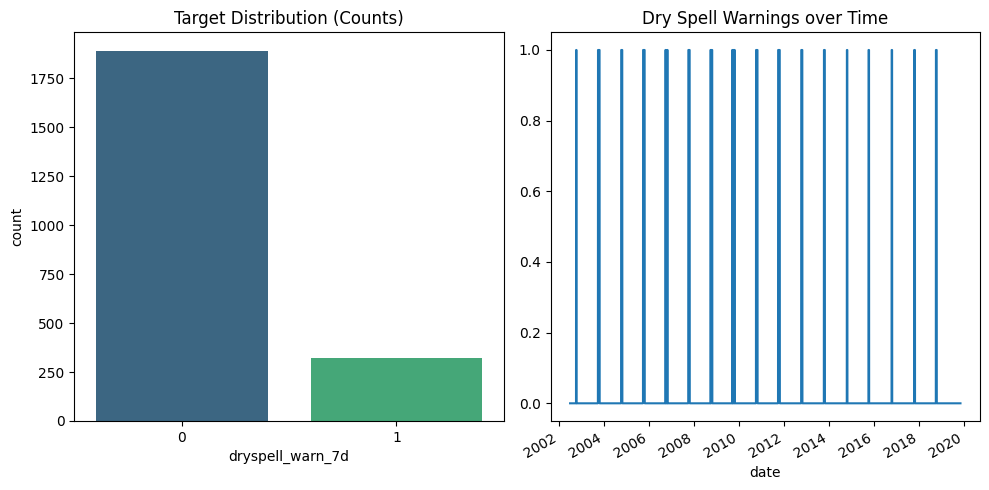

In [24]:
plt.figure(figsize=(10,5))

# Plot 1: Bar Chart (Magnitude)
plt.subplot(1, 2, 1)
sns.countplot(x='dryspell_warn_7d', data=train_merged, palette='viridis')
plt.title('Target Distribution (Counts)')

# Plot 2: Target over Time (Seasonality check)
plt.subplot(1, 2, 2)
train_merged.set_index('date')['dryspell_warn_7d'].plot()
plt.title('Dry Spell Warnings over Time')

plt.tight_layout()
plt.show()

In [25]:
# Missingness summary 
missing_pct = train_merged.isna().mean().sort_values(ascending=False)*100
print("--- Missingness Summary (%) ---")
# Only show columns with missing data
print(missing_pct[missing_pct > 0])

--- Missingness Summary (%) ---
Series([], dtype: float64)
